In [19]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import json
import numpy as np
import matplotlib.pyplot as plt

THRESHOLD_TIMESTAMPS = 5

In [3]:
def extract_json(filename: str):
    with open(filename, "r") as f:
        for line in f:
            session = json.loads(line)
            yield session["session"], session["events"]
total_lenght = extract_json("train.jsonl")
count = sum(1 for _ in extract_json("train.jsonl"))
print("Total sessions:", count)


Total sessions: 12899779


In [4]:
sessions = []

for i, (session_id, eventstotal) in enumerate(extract_json("train.jsonl")):
    aids, timestamps, events_type = [], [], []
    for event in eventstotal:
        aids.append(event["aid"])
        timestamps.append(event["ts"])
        events_type.append(event["type"])
        
    sessions.append({
            "session_id": i,
            "events": {
            "aid": aids,
            "timestamps": timestamps,
            "events_type": events_type    
            },
        })

In [5]:
class OttoDataSetSession(Dataset):
    def __init__(self, session):
        self.session = session
        self.event_map = {"clicks":1, "carts": 2, "orders": 3}

    def __len__(self) -> int:
        return len(self.session)


    def __getitem__(self, index):
        session = self.session[index]
                 
        events = session["events"]
        
        aids = torch.tensor(events["aid"], dtype=torch.int64)
        
        timestamps = torch.tensor(events["timestamps"], dtype=torch.long)
        
        events_type = torch.tensor( [self.event_map[e] for e in events["events_type"]], dtype=torch.int64)
        return {
            "session_id": torch.tensor(session["session_id"], dtype=torch.int64),
            "aid": aids,
            "timestamps": timestamps,
            "type": events_type
        }
    

In [14]:
dataset = OttoDataSetSession(sessions)
print(len(dataset))

lenghts = []
for i in range(0, len(dataset)):
    sample = dataset[i]["timestamps"]
    lenghts.append(len(sample))

print(np.mean(lenghts))
print(f"The total of the median is for this total of {len(dataset)} {np.median(lenghts)}")


12899779
16.799985178040647
The total of the median is for this total of 12899779 6.0


In [6]:
sessions_in_dataset = OttoDataSetSession(sessions)
print(f"Total len of the Sessions: {len(sessions_in_dataset)}")

session_sample_lenght = []
for i in range(len(sessions_in_dataset)):
    sample = sessions_in_dataset[i]["timestamps"]
    if len(sample) >= THRESHOLD_TIMESTAMPS:
        session_sample_lenght.append(len(sample))

print(np.mean(session_sample_lenght))
print(f"The total of the median is for this total of {len(session_sample_lenght)} {np.median(session_sample_lenght)}")


Total len of the Sessions: 12899779
26.522401204870317
The total of the median is for this total of 7624389 12.0


In [7]:
total_sessions = len(sessions_in_dataset)
kept_sessions = len(session_sample_lenght)
lost_sessions = total_sessions - kept_sessions

percent_lost = (lost_sessions / total_sessions) * 100
print(f"{percent_lost:.2f}%")


40.90%


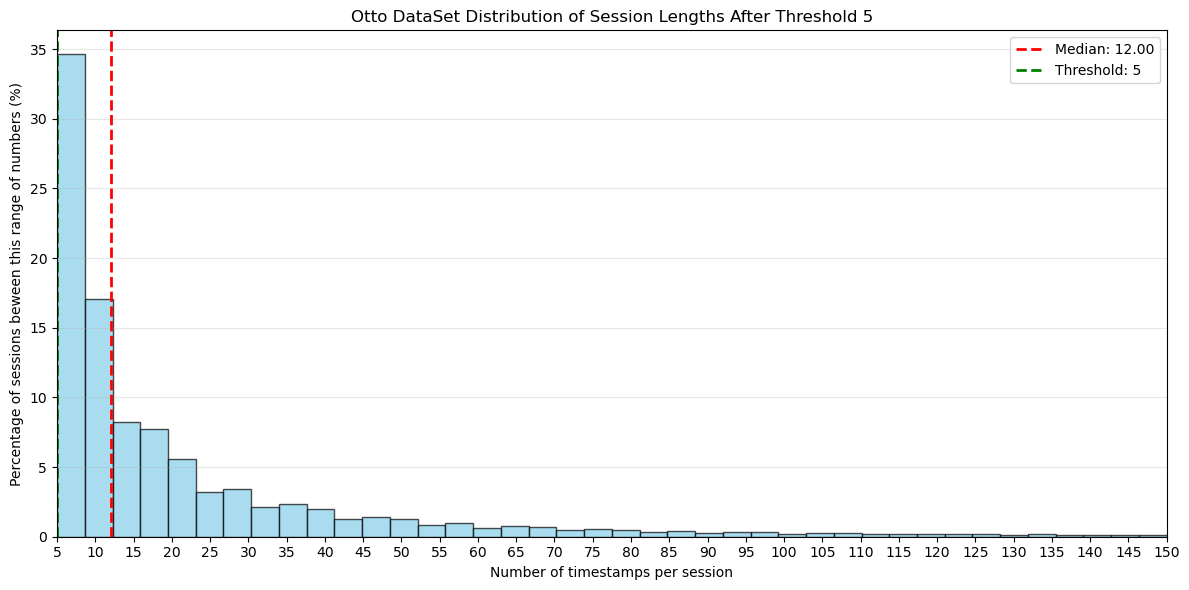

In [16]:
"""
Histograms 
"""


max_range = 150
filtered_for_plot = [x for x in session_sample_lenght if x <= max_range]

plt.figure(figsize=(12, 6))

counts, bins = np.histogram(filtered_for_plot, bins=40)
bin_width = bins[1] - bins[0]
counts_percentage = (counts / counts.sum()) * 100

plt.bar(
    bins[:-1],
    counts_percentage,
    width=bin_width,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    align="edge"
)


plt.axvline(
    np.median(session_sample_lenght),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median: {np.median(session_sample_lenght):.2f}"
)

plt.axvline(
    THRESHOLD_TIMESTAMPS,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Threshold: {THRESHOLD_TIMESTAMPS}"
)

plt.xlim(THRESHOLD_TIMESTAMPS, max_range)

plt.xticks(list(range(THRESHOLD_TIMESTAMPS, max_range+1, 5)))

plt.title(f"Otto DataSet Distribution of Session Lengths After Threshold {THRESHOLD_TIMESTAMPS}")
plt.xlabel("Number of timestamps per session")
plt.ylabel("Percentage of sessions beween this range of numbers (%)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
